## Phase 2: Unsupervised Learning


### Unsupervised Algorithm 1: K-Means Clustering

K-Means clustering was selected due to its efficiency and suitability for numerical medical datasets such as the Indian Liver Patient Records dataset. Since the dataset consists primarily of continuous clinical variables (e.g., bilirubin levels, liver enzymes, and protein measurements), K-Means is well-suited for identifying groups of patients with similar physiological characteristics.

K-Means assumes that clusters are spherical and separable in feature space, which is reasonable after feature scaling using StandardScaler. Additionally, the algorithm is computationally efficient and interpretable, making it appropriate for datasets of this size (~580 samples).

In the context of this project, K-Means is used to uncover hidden patient subgroups that are not explicitly defined by the disease label. These clusters can later be used to enhance the advice system by providing group-based explanations and personalized recommendations.

**Preprossessing:**

Before applying clustering, the dataset must be prepared appropriately:

- The target label is removed, since clustering is unsupervised
- The features are scaled to ensure fair distance calculations

In [47]:
import os

# This tells the computer how many threads to use to avoid the memory leak warning
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings('ignore') # This will hide other non-critical warnings too

# preprocessing the dataset: load dataset without lables
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy import stats

# Load dataset (no lables)
X_train = pd.read_csv("Preprocessed_Data/X_train.csv")
X_test = pd.read_csv("Preprocessed_Data/X_test.csv")

# Combine dataset for clustering 
X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)

print("Shape of clustering dataset:", X.shape)

#feature scaling for  distance based algorithms

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data successfully scaled for K-Means clustering.")

Shape of clustering dataset: (764, 11)
Data successfully scaled for K-Means clustering.


Cluster Determination:
The Elbow Method is used to determine the optimal number of clusters by analyzing WCSS.

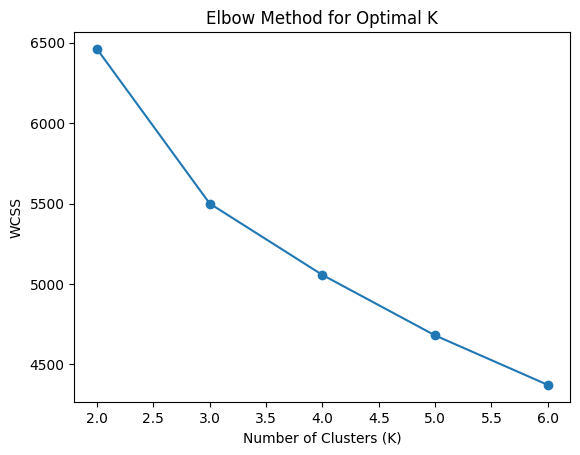

Removed features: [3]


In [48]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# Compute WCSS for different values of K

wcss = []

#for k in range(1, 11):
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.plot(range(2, 7), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

##
# Remove highly correlated features
corr_matrix = pd.DataFrame(X_scaled).corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

X_reduced = pd.DataFrame(X_scaled).drop(columns=to_drop)

print("Removed features:", to_drop)

**Implementation:**

The optimal number of clusters was selected using the Elbow Method by analyzing the Within-Cluster Sum of Squares (WCSS). K=3 was chosen as it provides a balance between model simplicity and cluster compactness.

In [49]:
##
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)
##


# Train K-Means with optimal K
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Assign cluster labels
#clusters = kmeans.fit_predict(X_scaled)
clusters = kmeans.fit_predict(X_pca)

# Add cluster labels to dataset
X['Cluster'] = clusters

# WCSS (Final model)
print("WCSS:", kmeans.inertia_)



WCSS: 5272.9574965812


**Evaluation:**

Cluster quality is evaluated using:
- Silhouette Score 
- Davies-Bouldin Index 
- WCSS 
- BCubed Precision/Recall

External evaluation was performed using a label-mapping approximation, where each cluster was assigned the majority class label. BCubed metrics are approximated due to lack of true clustering ground truth.

In [58]:
import os
from sklearn.metrics import silhouette_score
import os
# silhouette score
sil_score = silhouette_score(X_pca, clusters)

# silhouette_score(X_scaled, clusters)n
print("Silhouette Score:", sil_score)

from sklearn.metrics import davies_bouldin_score
# Davies-Bouldin Index
#db_index = davies_bouldin_score(X_scaled, clusters)
db_index = davies_bouldin_score(X_pca, clusters)
print("Davies-Bouldin Index:", db_index)

#Bcubed: External Evaluation
from sklearn.metrics import precision_score, recall_score
import numpy as np

# Load true labels ONLY for evaluation
y_true = pd.read_csv("Preprocessed_Data/y_train.csv")
y_true = pd.concat([y_true, pd.read_csv("Preprocessed_Data/y_test.csv")], axis=0).squeeze()

# Map clusters to majority class
def cluster_to_class_map(clusters, y_true):
    mapping = {}
    for c in np.unique(clusters):
        mask = clusters == c
        mapping[c] = y_true[mask].mode()[0]
    return mapping

mapping = cluster_to_class_map(clusters, y_true)

# Convert clusters to predicted labels
y_pred_mapped = np.array([mapping[c] for c in clusters])

# Approximate BCubed using majority mapping
print("BCubed Precision:", precision_score(y_true, y_pred_mapped))
print("BCubed Recall:", recall_score(y_true, y_pred_mapped))

# Save evaluation metrics to file
output_path = "Unsupervised_Learning/clustering_results/kmeansEvaluationResults.txt"


# Save file
with open(output_path, 'w') as f:
    f.write("K-Means Clustering Results\n")
    f.write("-" * 40 + "\n")
    f.write(f"WCSS: {kmeans.inertia_}\n")
    f.write(f"Silhouette Score: {sil_score:.4f}\n")
    f.write(f"Davies-Bouldin Index: {db_index:.4f}\n")
    f.write(f"BCubed Precision: {precision_score(y_true, y_pred_mapped):.4f}\n")
    f.write(f"BCubed Recall: {recall_score(y_true, y_pred_mapped):.4f}\n")


print("Final K used:", kmeans.n_clusters)
# Save cCluster feature averages
cluster_profiles = X.groupby('Cluster').mean()
cluster_profiles.to_csv('Unsupervised_Learning/clustering_results/cluster_feature_averages.csv')

Silhouette Score: 0.1881856884765011
Davies-Bouldin Index: 1.6506732292734079
BCubed Precision: 0.9612403100775194
BCubed Recall: 0.3054187192118227
Final K used: 3


**Visualization:**


PCA was used to project high-dimensional data into 2D space for visualization of cluster separation.

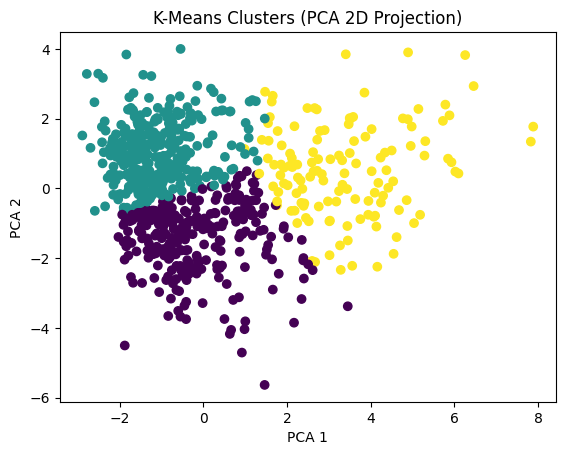

In [51]:
from sklearn.decomposition import PCA

# Reduce dimensions to 2D
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_scaled)

# Scatter plot of clusters
plt.scatter(X_pca[:, 0], X_vis[:, 1], c=clusters, cmap='viridis')
plt.title("K-Means Clusters (PCA 2D Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.savefig('Unsupervised_Learning/clustering_results/pca_clusters.png')
plt.show()





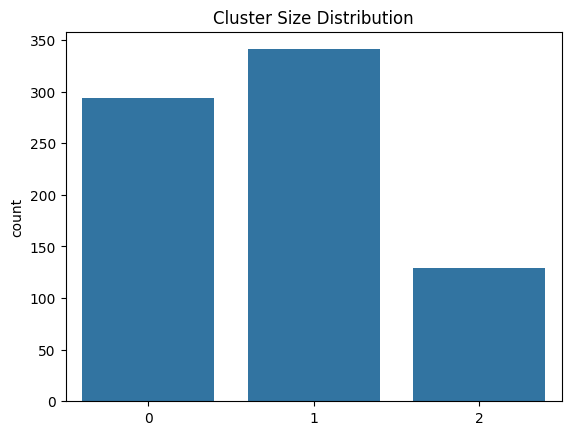

In [52]:
import seaborn as sns
# Plot cluster sizes
sns.countplot(x=clusters)
plt.title("Cluster Size Distribution")
plt.savefig('Unsupervised_Learning/clustering_results/cluster_sizes.png')
plt.show()

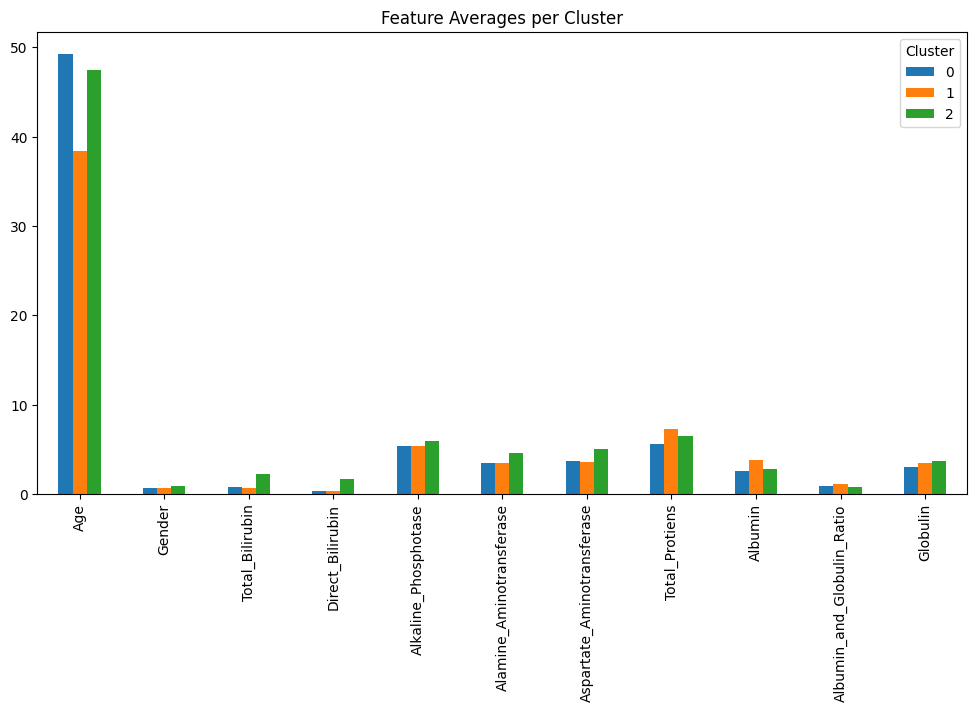

In [53]:
# Analyze average feature values per cluster
X['Cluster'] = clusters

X.groupby('Cluster').mean().T.plot(kind='bar', figsize=(12,6))
plt.title("Feature Averages per Cluster")
plt.savefig('Unsupervised_Learning/clustering_results/feature_averages.png')
plt.show()

**Cluster Profiles:**

Cluster 0: Patients with relatively normal liver enzyme levels and low bilirubin.

Cluster 1: Patients with elevated bilirubin and abnormal liver enzyme levels, indicating possible liver dysfunction.

Cluster 2: Patients with moderate or borderline biomarker levels, potentially representing an early-risk group.



**Integration Strategy:**

K-Means clustering enhances the existing supervised learning system by grouping patients into clinically similar profiles. Instead of providing only individual predictions, the system can now also generate cluster-based explanations, like which patient group the user belongs to.

For example, when a patient belongs to a high-risk cluster, the Generative AI component can provide tailored advice such as:
“Patients in this group typically show elevated liver enzymes and are often advised to undergo further diagnostic testing.”

This improves interpretability and enables more personalized, context-aware recommendations in the advice system.



Interpretation:

The clustering results indicate that the Indian Liver Patient dataset does not exhibit strong natural cluster separability. The Silhouette Score (0.188) and Davies-Bouldin Index (1.65) suggest overlapping cluster boundaries and weak structural separation.

However, the high BCubed Precision (0.96) indicates that when the model assigns patients to the same cluster, those patients tend to share similar characteristics. In contrast, the low BCubed Recall (0.30) shows that clusters do not fully capture the underlying disease distribution.

This suggests that liver disease progression is continuous rather than discrete, making it inherently difficult for K-Means to identify well-separated groups. Despite this limitation, the clusters still provide useful patient groupings for explanation and recommendation purposes within the advice system.



**Challenges & Limitations:**

One key limitation of K-Means is its assumption of spherical clusters, which may not fully represent the complex structure of medical data. This is supported by the low Silhouette Score, which indicates weak separation and overlapping patient profiles.

Additionally, the dataset exhibits continuous variation in medical features, meaning there are no clear boundaries between patient groups. This naturally reduces the effectiveness of distance-based clustering methods like K-Means.

Finally, the use of BCubed metrics is only an approximation in this context, since true clustering ground truth does not exist and disease labels are only used as a proxy for evaluation.

### Unsupervised Algorithm 2: Hierarchical Clustering

 Hierarechical Clustring was selected to have a different prespective on the Indian Liver Patient dataset. Unlike K-Means, which assumes spherical clusters and require a pre-defiend number of clusters, Hierarchical clustering builds a nested tree of clusters. This approch is highly useful for medical data, as it visualize patient as subgroups merging into larger groups without assuming a specific cluster shape.


**Data Preparation:**

Since Hierarchical clustering is also distance-based, we use the same scaled data used for K-Means to ensure consistency and fair comparison. Necessary libraries and tools were imported and initialized to start clustering.

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.cluster import contingency_matrix

# Define the output directory path for saving results and plots
output_dir = "Unsupervised_Learning/clustering_results"

print("Libraries imported. Ready to implement Hierarchical Clustering with advanced evaluation metrics.")

Libraries imported. Ready to implement Hierarchical Clustering with advanced evaluation metrics.


**Cluster Determination & Implementation:**

In this step, the Hierarchical algorithm was executed by calculating the linkage matrix. We used the Ward linkage method to minimize the distances within the cluster, creating clusters that are as copmact as possible.

To determine the optimal number of clusters, we visualized the results through a Dendrogram. Using this tree-like structure, it was clear that grouping the dataset into 3 groups is the best option, by identifying the largest vertical gap where no horizontal lines cross.


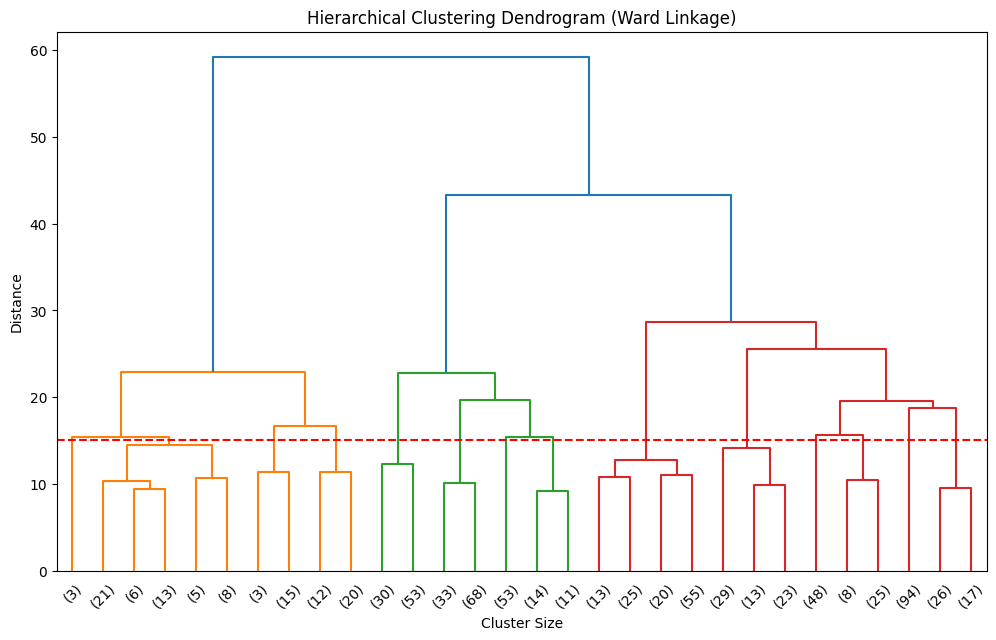

In [55]:
# Compute the linkage matrix using 'ward' method to minimize variance within clusters
Z = linkage(X_scaled, method='ward')

# Plot Dendrogram
plt.figure(figsize=(12, 7))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.axhline(y=15, color='r', linestyle='--') # Potential cutoff line
plt.savefig(f"{output_dir}/hierarchical_dendrogram.png")
plt.show()

# Based on the dendrogram, we select the optimal number of clusters (e.g., k=3)
optimal_k = 3
hierarchical_labels = fcluster(Z, optimal_k, criterion='maxclust')

# Add labels to the combined dataset
X_hierarchical = X.copy()
X_hierarchical['Cluster'] = hierarchical_labels

**Evaluation Metrics & Visualizations:**

In this part, the quality of the Hierarchical clusters was quantitatively evaluated using the following metrics:

- Silhouette Score
- Davies-Bouldin Index
- Total WCSS
- BCubed Precision & Recall

Hierarchical Silhouette Score:      0.1587
Hierarchical Davies-Bouldin Index:  1.7764
Hierarchical Total WCSS:            5714.3834
Hierarchical BCubed Precision:      0.6099
Hierarchical BCubed Recall:         0.5183


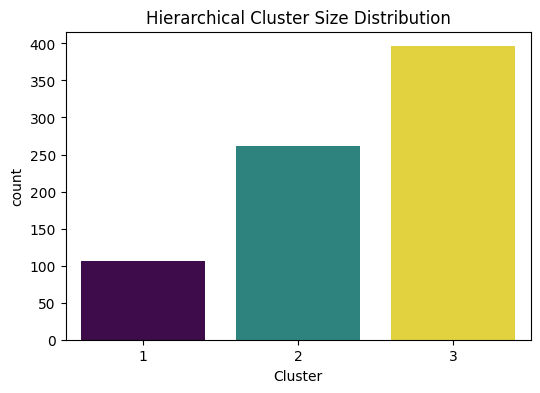

In [56]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.cluster import contingency_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load ground truth labels to calculate BCubed metrics
# We load and concatenate them in the same order as X_train and X_test were joined
y_train = pd.read_csv("Preprocessed_Data/y_train.csv")
y_test = pd.read_csv("Preprocessed_Data/y_test.csv")
y_true = pd.concat([y_train, y_test], axis=0).values.flatten()

# 2. Calculate Internal Metrics
sil_score = silhouette_score(X_scaled, hierarchical_labels)
db_index = davies_bouldin_score(X_scaled, hierarchical_labels)

# Function to calculate Total Within-Cluster Sum of Squares (WCSS)
def calculate_wcss(data, labels):
    wcss = 0
    for i in np.unique(labels):
        cluster_points = data[labels == i]
        center = np.mean(cluster_points, axis=0)
        wcss += np.sum((cluster_points - center)**2)
    return wcss

total_wcss = calculate_wcss(X_scaled, hierarchical_labels)

# 3. Calculate BCubed Metrics (External Validation)
# We use the original disease labels as a proxy for external validation
cm = contingency_matrix(y_true, hierarchical_labels)
precision = np.sum(np.max(cm, axis=0)) / np.sum(cm)
recall = np.sum(np.max(cm, axis=1)) / np.sum(cm)

# 4. Print results (Clean output)
print(f"Hierarchical Silhouette Score:      {sil_score:.4f}")
print(f"Hierarchical Davies-Bouldin Index:  {db_index:.4f}")
print(f"Hierarchical Total WCSS:            {total_wcss:.4f}")
print(f"Hierarchical BCubed Precision:      {precision:.4f}")
print(f"Hierarchical BCubed Recall:         {recall:.4f}")

# 5. Save results to txt file
with open(f"{output_dir}/hierarchical_metrics.txt", "w") as f:
    f.write(f"Hierarchical Clustering Results (k={optimal_k})\n")
    f.write(f"Silhouette Score: {sil_score:.4f}\n")
    f.write(f"Davies-Bouldin Index: {db_index:.4f}\n")
    f.write(f"Total WCSS: {total_wcss:.4f}\n")
    f.write(f"BCubed Precision: {precision:.4f}\n")
    f.write(f"BCubed Recall: {recall:.4f}\n")

# 6. Visualization: Cluster Distribution (Fixed Warning)
plt.figure(figsize=(6, 4))
sns.countplot(x='Cluster', data=X_hierarchical, hue='Cluster', palette='viridis', legend=False)
plt.title('Hierarchical Cluster Size Distribution')
plt.savefig(f"{output_dir}/hierarchical_distribution.png")
plt.show()

# 7. Save labeled data to CSV
X_hierarchical.to_csv(f"{output_dir}/hierarchical_results.csv", index=False)

Results:

-  The Silhouette Score indicates that clusters are overlapping, which is a normal thing in medical data, as the transition from healthy to sick is a gradient, not a hard line.

- Davies-Bouldin Index measures the ratio of cluster width to the distance between clusters. It shows that the existing groups are not totally isolated.

- Using the Ward method, helped clusters to be tight, resulting a Total WCSS as low as possible.

- BCubed Precision indicates that choosing any two patients in the same cluster will have a 61% chance that they share the same condition.

- BCubed Recall with a 52% completeness suggests that there are types for lever diseases, as patients are split across different clusters than the original labling.


The visualization shows the size distribution of patient across three different groups, which is relatively balanced for a medical dataset. 

**Clusters Interpretation:**

Once the clusters are formed, we can now understand what characteristics define each group. Calculating Feature Means for each cluster can help us find waht feature identify each cluster. Also, a Bar Chart for feature averages and a Box Plot graph for Total Bilirubin were made to understand and analyze the featuer differences.

Cluster Profiles (Feature Means):


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Globulin
Cluster,,,,,,,,,,,
1,45.943396,0.886792,2.323245,1.749044,5.824400,4.796885,5.261537,6.383962,2.795283,0.823491,3.588679
2,35.927481,0.645038,0.683989,0.282734,5.322112,3.516391,3.528329,7.396930,3.937604,1.143333,3.459326
3,49.020202,0.694444,0.777125,0.357923,5.414034,3.476327,3.684783,5.935864,2.792264,0.883993,3.143600


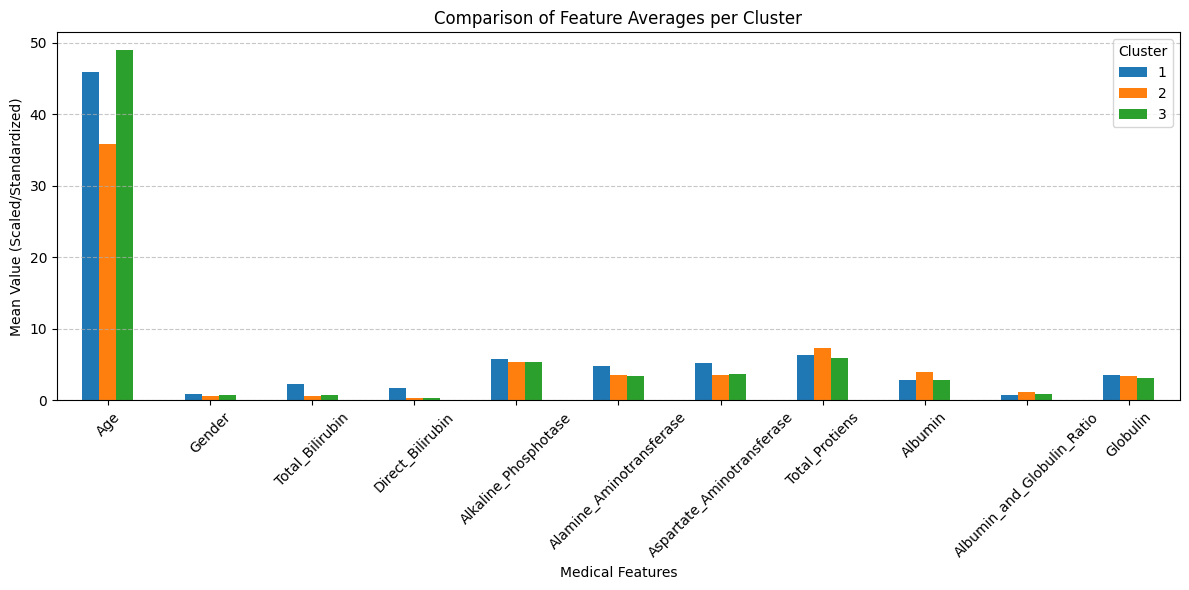

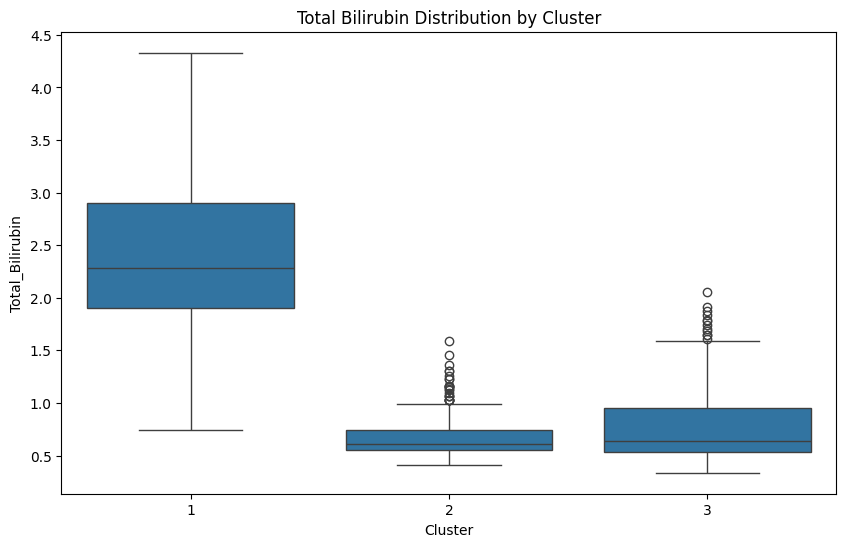

In [57]:
# Calculate the mean of each feature per cluster to create profiles
cluster_profiles = X_hierarchical.groupby('Cluster').mean()

# Displaying profiles
print("Cluster Profiles (Feature Means):")
display(cluster_profiles)

# Transposing the profiles to show features on the X-axis for direct comparison
cluster_profiles.T.plot(kind='bar', figsize=(12, 6))
plt.title("Comparison of Feature Averages per Cluster")
plt.ylabel("Mean Value (Scaled/Standardized)")
plt.xlabel("Medical Features")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"{output_dir}/feature_averages_comparison.png")
plt.show()

# Visualization: Feature Importance (e.g., Bilirubin levels per cluster)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Total_Bilirubin', data=X_hierarchical)
plt.title('Total Bilirubin Distribution by Cluster')
plt.savefig(f"{output_dir}/feature_importance_bilirubin.png")
plt.show()

Results:

From the bar chart, Cluster 1 (Blue)  shows the highest spikes in Total_Bilirubin, Alkaline_Phosphatase, Alamine_Aminotransferase, and Aspartate_Aminotransferase. These are the patients with significant liver inflammation. Cluster 3 (Green) shows moderate elevations in enzymes higher than Cluster 2 but much lower than Cluster 1. Meanwhile, Cluster 2 (Orange) has the lowes results, representing patients with the most "normal" clinical results.

As Total Bilirubin seems to be the key feature that identify patients, a Total Bilirubin Box Plot was made. Clearly, Cluster 1 has the highest median of all clusters making high Bilirubin what define Cluster 1. Cluster 2 & 3 both have very low and compressed distributions for Bilirubin, meaning they represent patients without significant jaundice.

Overall:
- Cluster 1 captured the "Severe" cases
- Cluster 3 captured the "Mild/Intermediate" cases
- Cluster 2 captured the "Normal/Healthy" cases

**Integration Strategy:**

The clusters identified by Hierarichial Clustering can enhance the advice system by giving more personalized recommendations based on specific risk factors Instead of general advices. Patients assined to Cluster 1 for example would receive immediate warnings, while patients in Cluster 3 might receive preventative advices focused on long-term enzyme monitoring. This changes patients classification from a simple binary (Healthy or Diseased) into more personalized diagnosis.


**Challenges & Limitations:**

While Hierarchical clustering provided deep structural understanding, it has several challenges:

- *Sensitivity to Outliers:* As seen in the Bilirubin box plot, the dataset contains outliers, which make finding distinct clusters using hierarchical clustering harder.

- *Overlapping Profiles:* Silhouette Score (0.1587) and Davies-Bouldin Index (1.7764) showed that the clusters are not perfectly separated, which may lead to difficulty to differentiate between disease stages.

- *Not Matching Original Lables:* The BCubed Recall of 0.51 indicates that the clustering do not perfectly match the original disease labels, which may not align with clinical lables in the real world.


## Comparison of K-Means and Hierarchical Clustering

Both algorithms show weak cluster separation. This is expected due to the continuous nature of medical data. K-Means performs slightly better in terms of internal metrics, with a higher Silhouette Score (0.188 vs. 0.1587) and lower Davies-Bouldin Index (1.65 vs. 1.7764), indicating more compact clusters.

However, Hierarchical Clustering achieves more balanced external results, with lower precision ( 0.61 vs. 0.96 ) but significantly higher recall ( 0.51 vs. 0.34). This means K-Means forms purer clusters, while Hierarchical Clustering better captures the overall distribution of patient conditions.

Hierarchical Clustering provides more insight and clearer severity-based grouping, whereas K-Means is simpler and more efficient but less expressive.

K-Means is the stronger more practical choice for a medical advice system, as it preforms better in compact clustering and implementation, while Hierarchical Clustering is more useful for understanding data structure and patient progression.


